In [151]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
%matplotlib inline  
# %matplotlib inline -> To ensure that plots generated by the Matplotlib library are displayed directly within the output cells of the notebook, rather than in a separate external window

In [152]:
X,y = make_blobs(n_samples = 1000, centers= 3, n_features = 2, random_state = 42)
X.shape  # print(X.shape)

(1000, 2)

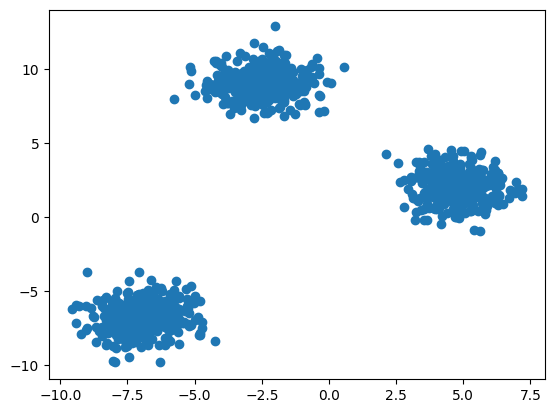

In [153]:
plt.scatter(X[:,0],X[:,1])

In [154]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.33, random_state= 42)
# 33% for testing & 67% for training


In [155]:
from sklearn.cluster import KMeans

In [156]:
# Elbow Method
# WCSS (Within-Cluster Sum of Squares)
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters = k, init = "k-means++")
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)

In [157]:
wcss

[44450.72387542038,
 24230.221501637512,
 1329.7219815435353,
 1161.0213561995843,
 1009.3407008368122,
 955.7572941026332,
 752.1027540492008,
 698.3734728509442,
 623.46019234302,
 564.4224641611139]

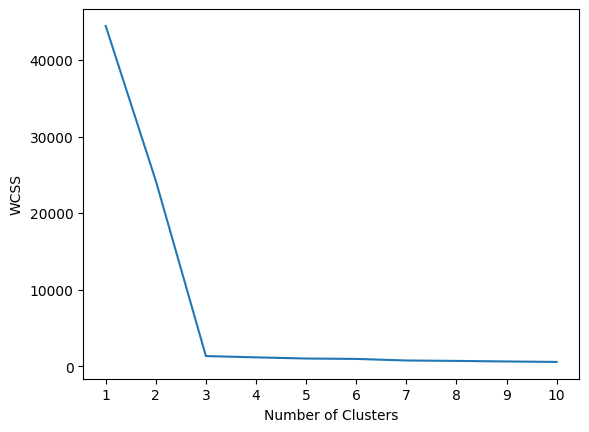

In [158]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [159]:
# Performance Metric
# Silhoutte Score
from sklearn.metrics import silhouette_score

In [160]:
silhouette_coefficients = []
for k in range(2,11):
  kmeans = KMeans(n_clusters = k, init = "k-means++")
  kmeans.fit(X_train)
  scores = silhouette_score(X_train, kmeans.labels_)
  silhouette_coefficients.append(scores)

In [161]:
silhouette_coefficients

[0.7024009416893275,
 0.8417121581954964,
 0.6634510660744966,
 0.4909459504238247,
 0.3337587987699787,
 0.33944728784784933,
 0.32531197182840665,
 0.32691754456637506,
 0.32552148737556247]

In [162]:
sil_avg = silhouette_score(X, y)
sil_avg

0.8435705873891368

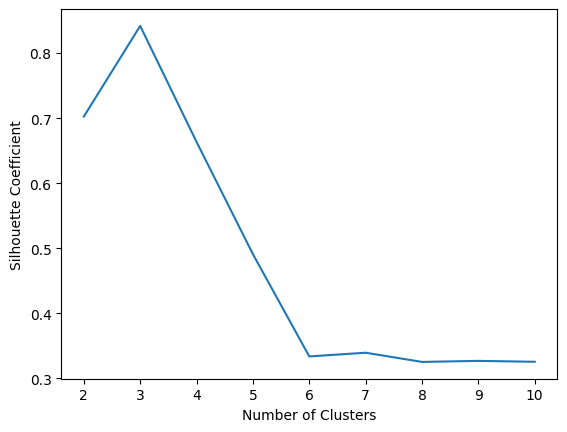

In [163]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [164]:
from kneed import KneeLocator

In [165]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow
k_optimal = int(kl.elbow)

In [166]:
kl.elbow, k_optimal

(np.int64(3), 3)

In [167]:
kmeans.predict(X_test)

array([9, 5, 5, 7, 2, 8, 3, 2, 7, 2, 4, 0, 2, 9, 9, 5, 5, 0, 8, 1, 5, 4,
       4, 0, 0, 6, 8, 2, 6, 9, 5, 6, 6, 1, 0, 0, 3, 1, 4, 0, 4, 1, 1, 0,
       4, 8, 6, 6, 4, 8, 3, 4, 9, 7, 1, 8, 4, 4, 8, 3, 6, 4, 1, 6, 1, 4,
       9, 5, 5, 4, 4, 8, 1, 8, 6, 8, 1, 8, 5, 3, 9, 1, 5, 6, 1, 1, 7, 5,
       1, 6, 5, 5, 2, 1, 1, 1, 3, 4, 5, 7, 4, 4, 5, 9, 1, 8, 4, 9, 5, 0,
       7, 3, 4, 1, 7, 5, 9, 2, 3, 1, 6, 5, 2, 7, 3, 4, 9, 9, 1, 1, 6, 0,
       8, 5, 9, 8, 4, 2, 9, 7, 2, 9, 3, 6, 5, 8, 4, 8, 8, 8, 0, 9, 1, 6,
       4, 2, 8, 8, 6, 6, 7, 2, 8, 3, 4, 1, 1, 4, 5, 5, 0, 9, 5, 0, 0, 6,
       2, 7, 1, 0, 9, 3, 5, 6, 3, 6, 9, 6, 3, 8, 9, 4, 2, 1, 7, 4, 1, 2,
       1, 9, 6, 9, 7, 0, 4, 2, 9, 6, 5, 4, 2, 4, 5, 3, 1, 0, 6, 4, 8, 6,
       7, 0, 8, 3, 8, 0, 1, 9, 2, 9, 4, 3, 0, 5, 2, 8, 1, 6, 6, 8, 4, 0,
       1, 5, 8, 9, 9, 4, 3, 2, 4, 4, 7, 2, 6, 6, 4, 4, 3, 8, 1, 3, 9, 0,
       4, 5, 7, 1, 5, 0, 9, 0, 8, 6, 0, 3, 0, 2, 4, 3, 3, 1, 3, 1, 5, 6,
       1, 8, 7, 0, 3, 4, 9, 6, 6, 0, 5, 0, 0, 0, 1,

In [168]:
kmeans = KMeans(n_clusters = k_optimal, init = "k-means++")
y_labels = kmeans.fit_predict(X_train)
y_labels.shape

(670,)

Text(0.5, 1.0, 'Final K-Means Clustering (k=3), Silhouette Score: 0.8436')

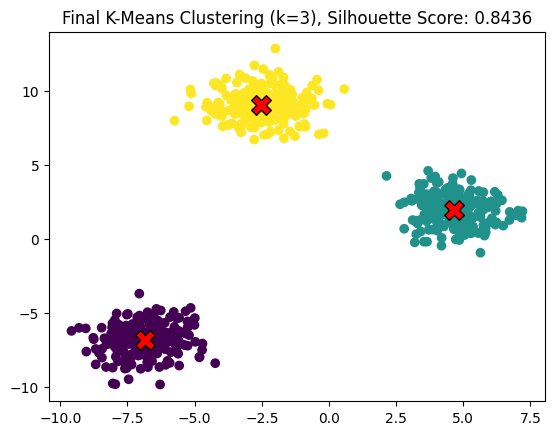

In [211]:
centroids = kmeans.cluster_centers_
plt.scatter(X_train[:,0], X_train[:,1], c= y_labels)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolors='black')
plt.title(f'Final K-Means Clustering (k={k_optimal}), Silhouette Score: {sil_avg:.4f}')  # .4f is used to display 4 decimal places